In [2]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("data/Carbon Emission.csv")
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [3]:
df.isnull().sum()

Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [4]:
df.columns

Index(['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source',
       'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill',
       'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km',
       'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour',
       'How Many New Clothes Monthly', 'How Long Internet Daily Hour',
       'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission'],
      dtype='object')

In [5]:
f = df[
    [
        'Transport',
        'Vehicle Monthly Distance Km',
        'Energy efficiency',
        'Waste Bag Weekly Count',
        'CarbonEmission'
    ]
]

In [6]:
f.head()

,Transport,Vehicle Monthly Distance Km,Energy efficiency,Waste Bag Weekly Count,CarbonEmission
0,public,210,No,4,2238
1,walk/bicycle,9,No,3,1892
2,private,2472,Sometimes,1,2595
3,walk/bicycle,74,Sometimes,3,1074
4,private,8457,Yes,1,4743


In [7]:
f.isnull().sum()

Transport                      0
Vehicle Monthly Distance Km    0
Energy efficiency              0
Waste Bag Weekly Count         0
CarbonEmission                 0
dtype: int64

In [8]:
f=f.drop_duplicates()

In [9]:
f.duplicated().sum()

np.int64(0)

In [10]:
print(f.dtypes)

Transport                      object
Vehicle Monthly Distance Km     int64
Energy efficiency              object
Waste Bag Weekly Count          int64
CarbonEmission                  int64
dtype: object


In [11]:
f['CarbonEmission'].unique()

array([2238, 1892, 2595, ..., 4812,  440, 3283], shape=(3509,))

In [12]:
transport=f.groupby('Transport')['CarbonEmission'].mean()
print(transport)

Transport
private         2980.878012
public          1965.789314
walk/bicycle    1879.738547
Name: CarbonEmission, dtype: float64


In [13]:

energy=f.groupby('Energy efficiency')['CarbonEmission'].mean()
print(energy)

Energy efficiency
No           2286.656628
Sometimes    2269.151314
Yes          2252.135404
Name: CarbonEmission, dtype: float64


In [14]:
waste=f.groupby('Waste Bag Weekly Count')['CarbonEmission'].mean()
print(waste)

Waste Bag Weekly Count
1    2018.880087
2    2106.619419
3    2174.628036
4    2273.047749
5    2359.130000
6    2447.619176
7    2489.418246
Name: CarbonEmission, dtype: float64


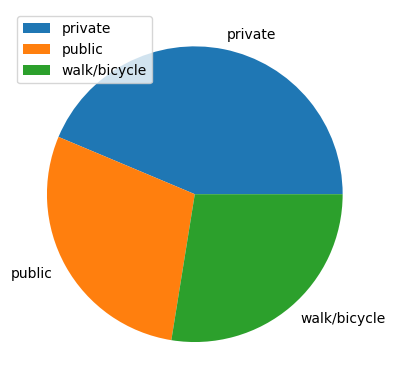

In [15]:
import matplotlib.pyplot as plt
plt.pie(transport,labels=transport.index)
plt.legend()

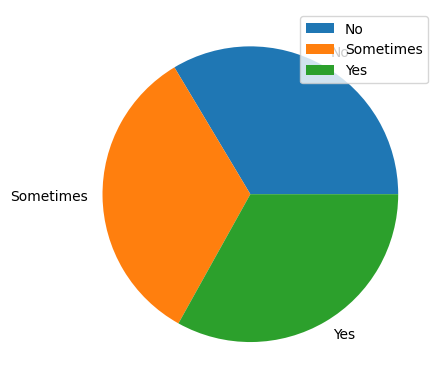

In [16]:
plt.pie(energy,labels=energy.index)
plt.legend()

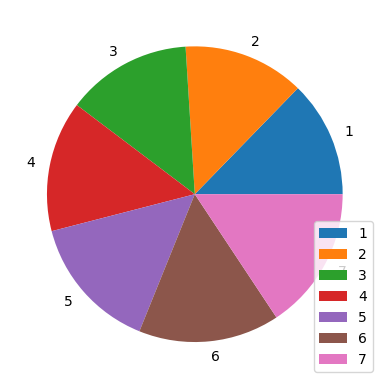

In [17]:
plt.pie(waste,labels=waste.index)
plt.legend()

In [18]:
f.shape

(10000, 5)

In [19]:
f.to_excel("A_Vignesh_Balaji_CleanedDataset.xlsx", index=False)

In [20]:
import os
print(os.getcwd())

C:\Users\A.Vignesh Balaji


In [21]:
f.nlargest(5, 'CarbonEmission')

,Transport,Vehicle Monthly Distance Km,Energy efficiency,Waste Bag Weekly Count,CarbonEmission
9773,private,9791,Yes,6,8377
4670,private,9883,No,5,7531
1183,private,9739,No,1,7337
9394,private,6387,Yes,5,7295
1179,private,9096,Sometimes,2,7226


In [22]:
f.nsmallest(5, 'CarbonEmission')

,Transport,Vehicle Monthly Distance Km,Energy efficiency,Waste Bag Weekly Count,CarbonEmission
2292,walk/bicycle,11,Yes,1,306
7004,walk/bicycle,44,No,1,369
7799,walk/bicycle,92,Yes,2,392
1213,walk/bicycle,10,Sometimes,1,412
3786,walk/bicycle,31,Sometimes,1,436


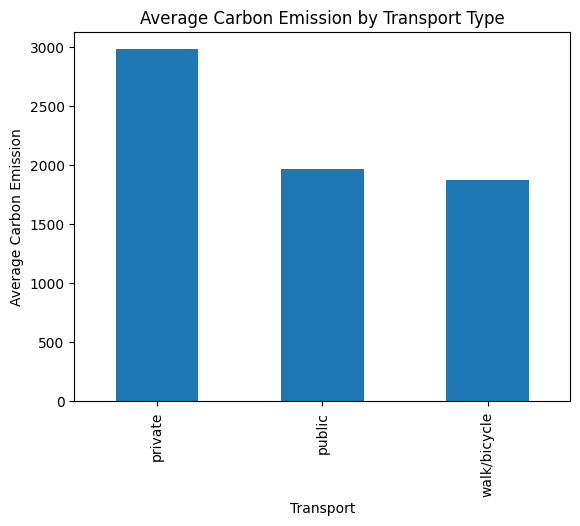

In [23]:
transport = f.groupby('Transport')['CarbonEmission'].mean()

transport.plot(kind='bar')
plt.title('Average Carbon Emission by Transport Type')
plt.xlabel('Transport')
plt.ylabel('Average Carbon Emission')
plt.show()

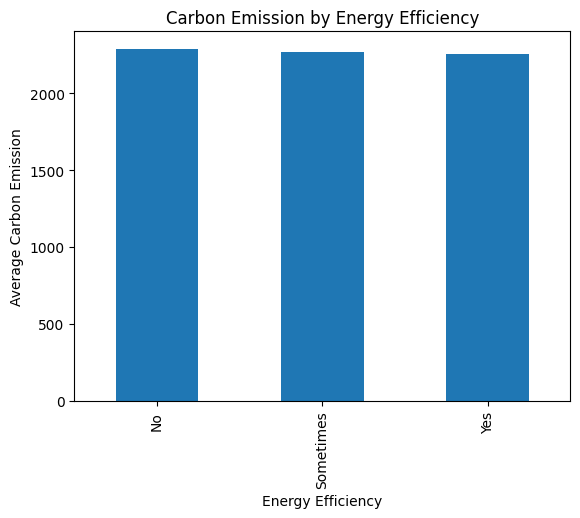

In [24]:
energy = f.groupby('Energy efficiency')['CarbonEmission'].mean()

energy.plot(kind='bar')
plt.title('Carbon Emission by Energy Efficiency')
plt.xlabel('Energy Efficiency')
plt.ylabel('Average Carbon Emission')
plt.show()

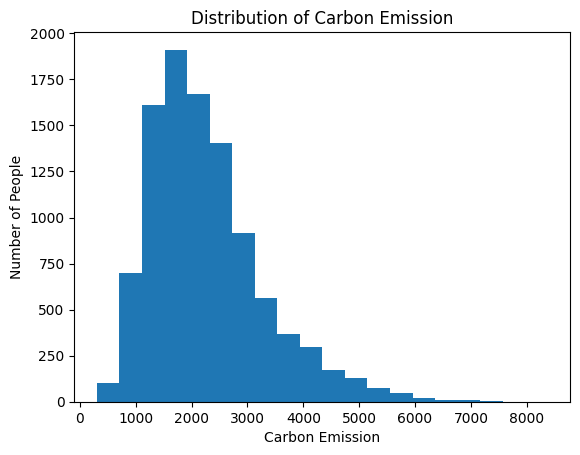

In [25]:
plt.hist(f['CarbonEmission'], bins=20)
plt.title('Distribution of Carbon Emission')
plt.xlabel('Carbon Emission')
plt.ylabel('Number of People')
plt.show()

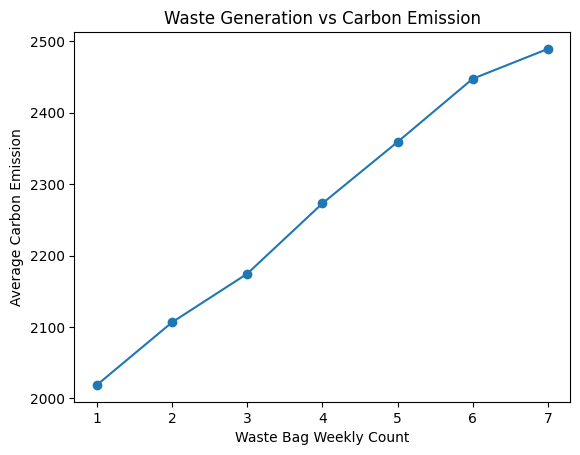

In [27]:
waste = f.groupby('Waste Bag Weekly Count')['CarbonEmission'].mean()

waste.plot(kind='line', marker='o')
plt.title('Waste Generation vs Carbon Emission')
plt.xlabel('Waste Bag Weekly Count')
plt.ylabel('Average Carbon Emission')
plt.show()

In [ ]:
f.head()